# Машинное обучение, ФКН ВШЭ

# Практическое задание 11. Несбалансированные задачи

## Общая информация
Дата выдачи: 24.04.2025

Мягкий дедлайн: 13.05.2025 23:59 MSK

Жесткий дедлайн: 18.05.2025 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-xx-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

## О задании

В этом задании мы разберем основные техники работы в задачах, где один из классов занимает существенно меньшую долю выборки, чем остальные. Для простоты мы обойдемся бинарной задачей, тем не менее, во многом данные методы можно перенести и на задачи с б**о**льшим числом классов. Кроме того, вы получите очередной бесценный опыт исследования случайной библиотеки случайных индусов с нуля.

In [29]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from tqdm.auto import tqdm

**Задание -1 (1 балл)**. EDA

В качестве данных для нашей работы возьмем выложенный на kaggle датасет транзакций, в котором нужно выискивать мошеннические проводки: [клик](https://www.kaggle.com/mlg-ulb/creditcardfraud). Данная задача по определению подходит под несбалансированную, что можно сказать даже без наличия каких-либо данных (понятно, что среди всех транзакций клиентов очень малая часть будет мошеннической).

Загрузим данные, проведем некоторые классические манипуляции.

In [30]:
# %%bash
# kaggle datasets download -d mlg-ulb/creditcardfraud
# unzip creditcardfraud.zip

In [31]:
df = pd.read_csv('./data/creditcard.csv')

In [32]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Наши данные были анонимизированы. Мы имеем 30 признаков, из которых 28 - это результаты PCA-преобразования на исходном датасете. Еще 2 признака представляют собой время в секундах, прошедшее с момента первой транзакции в датасете, и размер транзакции. Скажите, какова доля положительных объектов в выборке?

In [33]:
df['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [34]:
print(f'{492 / (492 + 284315) * 100:0.4f}%')

0.1727%


Начнем с обработки времени. Секунды сами по себе не несут большой информации о зависимостях в данных, попробуйте по ним создать признаки "час" (от 0 до 23) и "день" (от 0 до ...) в аналогичной манере (принимая первый объект выборки за начальную точку). Сколько дней покрывают данные?

In [35]:
df['hour'] = (df.Time // (60 * 60))
df['day'] = df.hour // 24
df.hour = df.hour % 24

In [36]:
df[['hour', 'day']]

,hour,day
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
284802,23.0,1.0
284803,23.0,1.0
284804,23.0,1.0
284805,23.0,1.0


Постройте следующие графики:

1. Распределение числа транзакций по каждому часу (line-plot).
2. Распределение доли мошеннических транзакций по каждому часу (line-plot)
3. То же самое для дней (здесь можно использовать bar-plot, так как дней должно быть немного).

Какие выводы можно сделать из графиков? На ваш взгляд, как можно связать полученные нами часы с реальными часами в сутках?

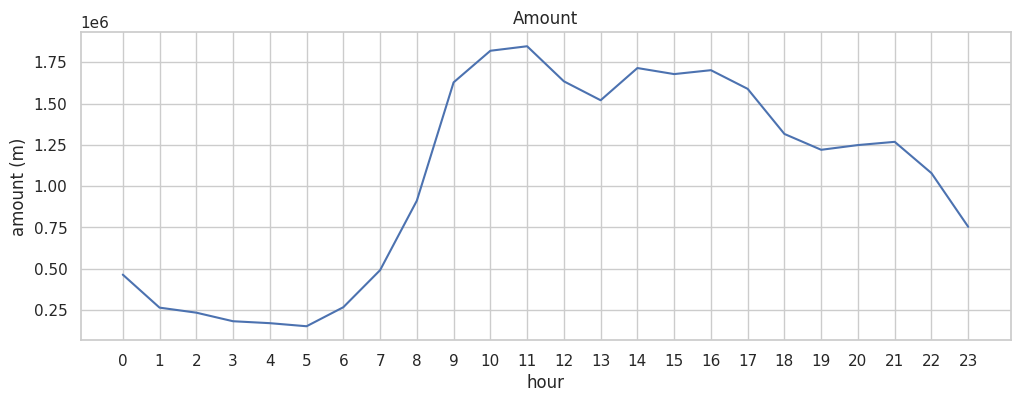

In [37]:
amount = df.groupby('hour')['Amount'].sum()
plt.figure(figsize=[12, 4])
plt.title('Amount')
plt.plot(amount)
plt.xticks(range(24))
plt.ylabel('amount (m)')
plt.xlabel('hour')
plt.show()

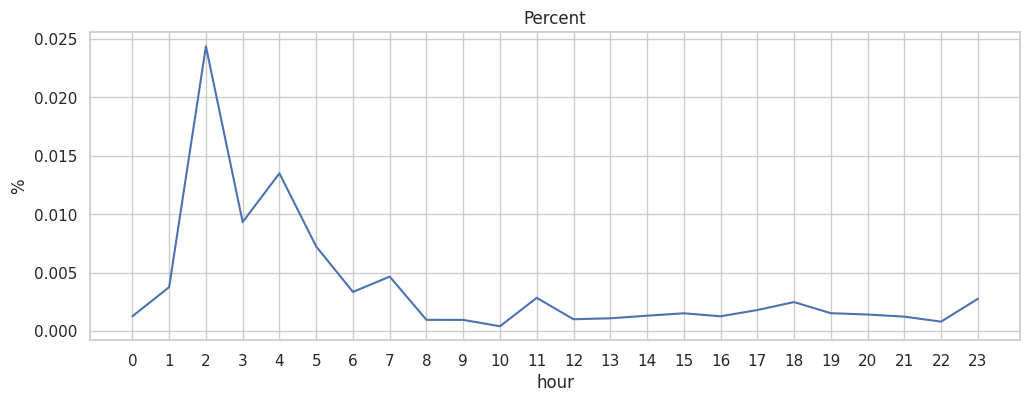

In [38]:
dist = df.groupby('hour')['Class'].sum().values / amount.values * 100
plt.figure(figsize=[12, 4])
plt.title('Percent')
plt.plot(dist)
plt.xticks(range(24))
plt.xlabel('hour')
plt.ylabel('%')
plt.show()

Text(0, 0.5, 'amount (1e7)')

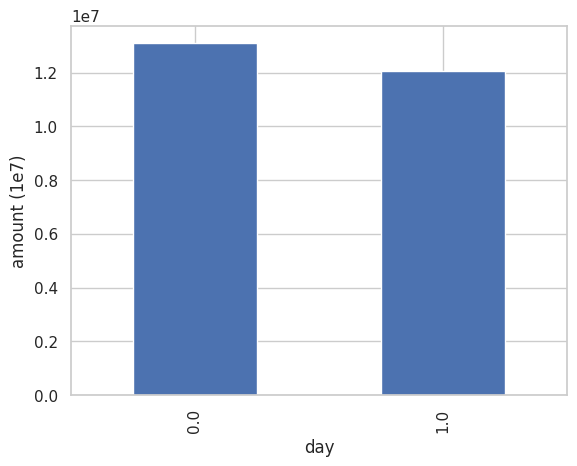

In [39]:
amount = df.groupby('day')['Amount'].sum()
amount.plot(kind='bar')
plt.ylabel('amount (1e7)')

In [40]:
amount

day
0.0    13093975.05
1.0    12068614.96
Name: Amount, dtype: float64

Text(0, 0.5, '%')

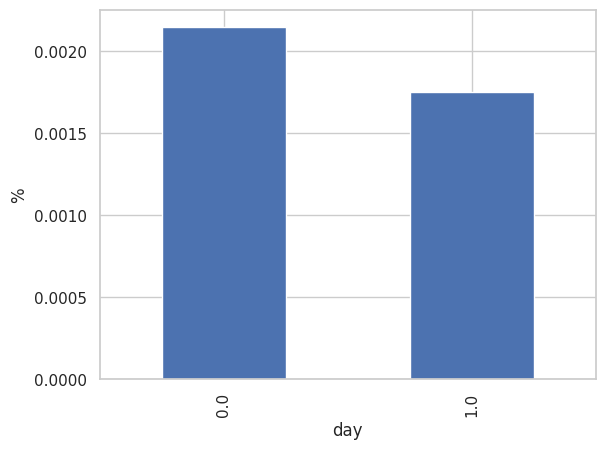

In [41]:
(df.groupby('day')['Class'].sum() / amount * 100).plot(kind='bar')
plt.ylabel('%')

С анонимизированными признаками вряд ли можно придумать что-то интересное. Попробуйте (например, с помощью корреляции?) выбрать несколько наиболее важных признаков и поглядеть на различия в их распределении для разных классов.

Теперь давайте разделим данные. Отделите хронологически последние 20% транзакций и поделите их пополам (также хронологически, т.е. без перемешивания) на валидационные и тестовые. Это разбиение не совсем корректно (как можно было заметить, мошеннические транзакции имеют разное распределение во времени - по-хорошему, нам стоило бы выделить целые сутки записей как под валидацию, так и под тест), тем не менее, мы не сможем получить больше данных для адекватного контроля, поэтому обойдемся этим. 

In [42]:
l = len(df)
last20 = int(l * 0.2)
t = df[-last20:]
train = df[:-last20]
len(t)

56961

In [43]:
len(train) + len(t) == len(df)

True

In [44]:
val_size = int(last20 / 2)
test, val = t[:val_size], t[val_size:]
len(test) + len(val), len(t)

(56961, 56961)

# Часть 1. Несбалансированная классификация.

**Задание 0. (1 балл)**: перед началом работы давайте поговорим о том, как мы будем оценивать качество. Классические метрики для качества классификации чаще всего "ломаются" на задачах с сильным перекосом. Чему будет равно значение accuracy для наивного предсказания (= мажорный класс для каждого объекта)? (можете не отвечать, просто подумайте)

Из курса МО-1 вам уже известно, что мы можем использовать в таких задачах `AUC-PR` и получать адекватные показатели. Можно сказать, что `AUC-PR` представляет собой матожидание `precision` по распределению, заданному выигрышем в `recall` при смене порога. 

In [45]:
from sklearn.metrics import precision_score as precision, recall_score as recall, auc, precision_recall_curve

def auc_pr(y_true, y_pred):
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    return auc(recall, precision)

Тем не менее, существуют и другие, не менее интересные метрики. Одной из таких метрик является коэффициент Каппа Коэна, представляющий собой нормализованную `accuracy`:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Данная метрика служит в качестве меры согласованности между двумя независимыми предсказателями, но ничего не знает про "верные" и "предсказанные" метки (в отличие от многих других метрик машинного обучения). Здесь $p_o$ - доля согласованных предсказаний, а $p_e$ - доля согласованных предсказаний, которая могла бы получиться при случайных ответах предсказателей. В нашем случае это работает так:

• В качестве $p_o$ берем accuracy

• В качестве $p_e$ примем следующую величину - вероятность случайного соглашения позитивных ответов (произведение долей позитивных ответов в обоих предсказаниях) плюс вероятность случайного соглашения негативных ответов (произведение долей негативных ответов в обоих предсказаниях)

Метрика принимает значения от -1 до 1, где 1 - полная согласованность, 0 - согласованность на уровне рандома, -1 - совсем плохо. Как уже говорилось, метрика не различает "верные" и "предсказанные" метки, поэтому является симметричной (можете использовать это для отладки):

In [46]:
from sklearn.metrics import accuracy_score as accuracy

def kappa(y_true, y_pred):
    p_o = accuracy(y_true, y_pred)
    a = y_true.mean() * y_pred.mean()
    b = (1 - y_true.mean()) * (1 - y_pred.mean())
    p_e = a + b
    return (p_o - p_e) / (1 - p_e)

Еще одной метрикой в такой задаче служит коэффициент корреляции Мэтьюза, выражающийся в терминах матрицы ошибок следующим образом:

$$\text{MCC} = \frac{TP\times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$ 

Метрика принимает значения от -1 до 1, интерпретируемые аналогичным образом. 

In [47]:
def MCC(y_true, y_pred) -> float:
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))

    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    d = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    if d == 0.0:
        return 0.0
    
    return float(tp * tn - fp * fn) / np.sqrt(d)

Обратите внимание, что эти метрики вычисляются на бинаризованных предсказаниях, поэтому может иметь смысл дополнительная настройка порога бинаризации.

Давайте проверим, что наши метрики действительно подходят под задачу. Вычислите их значения для наивного предсказания (aka мажорный класс для всех объектов):

In [57]:
train.to_csv('train.csv')
val.to_csv('val.csv')
test.to_csv('test.csv')

In [48]:
X_train, y_train = train.drop(columns='Class'), train['Class']
X_test, y_test = test.drop(columns='Class'), test['Class']
X_val, y_val = val.drop(columns='Class'), val['Class']

In [49]:
y_pred = np.zeros(len(test))

In [31]:
print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_pred):<8.4f}')
print(f'{"Kappa:":<8} {kappa(y_test, y_pred):<8.4f}')
print(f'{"MCC:":<8} {MCC(y_test, y_pred):<8.4f}')

AUC-PR:  0.5009  
Kappa:   0.0000  
MCC:     0.0000  


Давайте запустим бейзлайн-решение для нашей задачи. С чего же начнем? Возьмите `catboost` и обучите его классификатор на наших данных (используйте все признаки). Вычислите значения всех метрик на тестовой части, для контроля переобучения используйте валидационную (здесь и далее везде, где фигурирует `catboost`). 

In [32]:
from catboost import CatBoostClassifier

classifier = CatBoostClassifier(
    iterations=1000,
    depth=3,
    loss_function='CrossEntropy',
    eval_metric='AUC',
    random_seed=12
)

classifier = classifier.fit(
    X_train, 
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    verbose=100
)

y_probs = classifier.predict_proba(X_test)[:, 1]

y_pred = (y_probs > 0.5).astype(int)

print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_pred):<8.4f}')
print(f'{"Kappa:":<8} {kappa(y_test, y_pred):<8.4f}')
print(f'{"MCC:":<8} {MCC(y_test, y_pred):<8.4f}')

0:	test: 0.8954876	best: 0.8954876 (0)	total: 66.7ms	remaining: 1m 6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9563327147
bestIteration = 34

Shrink model to first 35 iterations.
AUC-PR:  0.7740  
Kappa:   0.7069  
MCC:     0.7394  


Если вы все сделали правильно, у вас должны были получиться значения в районе 0.7.

**Задание 1. (1 балл)**. Многие реализации методов предлагают встроенные способы для борьбы с нашей проблемой. Самое часто встречающееся решение - просто добавить вес в функции потерь для минорного класса (таким образом, ошибка на объекте минорного класса будет весить больше, чем для мажорного). В `catboost` это также реализовано, причем для бинарной задачи это можно сделать целыми двумя способами (можете выбрать любой, на свой вкус, автор задания предпочитает отдельный скейлинг для минорного класса). Чаще всего в качестве веса берется отношение числа объектов мажорного класса к числу минорного. Попробуйте обучить модель с таким скалированием и сравните метрики на тестовой части с бейзлайном.

In [33]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'ratio: {ratio:0.2f}')

classifier_scaled = CatBoostClassifier(
    iterations=1000,
    depth=3,
    scale_pos_weight=ratio,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=12
)

classifier_scaled = classifier_scaled.fit(
    X_train, 
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    verbose=100
)

y_probs_scaled = classifier_scaled.predict_proba(X_test)[:, 1]

y_pred_scaled = (y_probs_scaled > 0.5).astype(int)

print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_probs_scaled):<8.4f}')
print(f'{"Kappa:":<8} {kappa(y_test, y_pred_scaled):<8.4f}')
print(f'{"MCC:":<8} {MCC(y_test, y_pred_scaled):<8.4f}')

ratio: 545.39
Learning rate set to 0.121129
0:	test: 0.8863285	best: 0.8863285 (0)	total: 13ms	remaining: 13s
100:	test: 0.9698274	best: 0.9870835 (51)	total: 1.53s	remaining: 13.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9870834917
bestIteration = 51

Shrink model to first 52 iterations.
AUC-PR:  0.8319  
Kappa:   0.2334  
MCC:     0.3481  


Поскольку данный вес будет являться гиперпараметром метода, было бы опрометчиво остановиться на одном значении (тем более, с большой вероятностью у вас все сломалось). Запустите перебор для этого гиперпараметра на валидационной выборке (используйте `PR-AUC`), подберите оптимальный порог бинаризации для $\kappa$ или $\text{MCC}$. Для лучшего найденного веса и порога вычислите все метрики на тестовой части. 

При этом можете также проверить отдельное скалирование в большую сторону для мажорного класса (т.е. веса минорного сделать меньше 1) и экстремальные скалирования (т.е. веса минорного больше, чем в начале этого задания). Какой вес получился оптимальным?

In [34]:
weights = [1, 10, 50, 180, 545, 800]
best_weight = 1
best_auc_pr = -1

vals = []

for weight in weights:
    model = CatBoostClassifier(
        iterations=1000,
        depth=3,
        scale_pos_weight=weight,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=12,
        verbose=0
    )
    model.fit(
        X_train, 
        y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )
    val = auc_pr(y_val, model.predict_proba(X_val)[:, 1])
    vals.append(val)

    if val > best_auc_pr:
        best_auc_pr = val
        best_weight = weight

In [35]:
print('(weight, auc-pr)')
print(*zip(weights, np.round(vals, 2)), sep='\n')

(weight, auc-pr)
(1, 0.56)
(10, 0.54)
(50, 0.66)
(180, 0.64)
(545, 0.67)
(800, 0.43)


In [36]:
classifier_best = CatBoostClassifier(
    iterations=1000,
    depth=3,
    scale_pos_weight=best_weight,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=12,
    verbose=0
)
classifier_best.fit(
    X_train, 
    y_train, 
    eval_set=(X_val, y_val), 
    early_stopping_rounds=50
)

y_probs_val = classifier_best.predict_proba(X_val)[:, 1]
_, _, thresholds = precision_recall_curve(y_val, y_probs_val)
best_threshold = 0.5
best_mcc = -1

for threshold in thresholds:
    y_pred_val = (y_probs_val >= threshold).astype(int)
    mcc_val = MCC(y_val, y_pred_val)
    if mcc_val > best_mcc:
        best_mcc = mcc_val
        best_threshold = threshold

y_probs = classifier_best.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= best_threshold).astype(int)

print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_probs):<8.4f}')
print(f'{"Kappa:":<8} {kappa(y_test, y_pred):<8.4f}')
print(f'{"MCC:":<8} {MCC(y_test, y_pred):<8.4f}')

AUC-PR:  0.8124  
Kappa:   0.7952  
MCC:     0.8124  


**Задание 2. (1 балл)**. На самом деле, то, что мы сейчас делали, очень схоже с другой распространенной техникой - оверсэмплингом. Фактически, мы можем продублировать все объекты минорного класса и получить тот же эффект, какой был бы при использовании веса, равного 2. Тем не менее, такой подход - это лишь малая часть того, что мы можем проделать с целью повысить число объектов минорного класса. 

Для продолжения работы установим библиотеку [imbalanced-learn](https://imbalanced-learn.org/stable/):

In [37]:
!pip3 install imbalanced-learn
# conda install -c conda-forge imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


Первый метод, которым мы воспользуемся, называется SMOTE (его вы уже разбирали на лекции). Кратко напомним суть: мы выбираем случайного кандидата среди $k$ ближайших соседей объекта минорного класса, затем берем точку на отрезке между двумя объектами (т.е. выпуклую комбинацию со случайными коэффициентами) и добавляем в выборку. 

In [38]:
from imblearn.over_sampling import SMOTE

Используйте SMOTE для ресэмплинга обучающей выборки, на новой выборке обучите модель (вес положительных объектов скалировать не нужно). Замерьте качество на тестовой выборке (**важно!** не преобразовывайте валидационную и тестовую выборку никак - мы не хотим отслеживать качество на объектах, которых в реальности не существует). Сравните полное выравнивание выборки с частичным (т.е. таким, что баланс классов улучшается, но не достигает равенства - скажем, 1:2 и 1:10).

In [39]:
from imblearn.over_sampling import SMOTE

ratios = [0.1, 0.25, 0.5, 1.0]

for ratio in ratios:
    smote = SMOTE(sampling_strategy=ratio, random_state=12)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    
    model = CatBoostClassifier(
        iterations=1000,
        depth=3,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=12,
        verbose=0
    )

    model.fit(X_resampled, y_resampled, eval_set=(X_val, y_val), early_stopping_rounds=50)

    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= best_threshold).astype(int)
    
    print(f'{"Ratio:":<8} {ratio:<8.4f}')
    print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_probs):<8.4f}')
    print(f'{"Kappa:":<8} {kappa(y_test, y_pred):<8.4f}')
    print(f'{"MCC:":<8} {MCC(y_test, y_pred):<8.4f}')
    print()

Ratio:   0.1000  
AUC-PR:  0.8315  
Kappa:   0.8219  
MCC:     0.8353  

Ratio:   0.2500  
AUC-PR:  0.8269  
Kappa:   0.8087  
MCC:     0.8239  

Ratio:   0.5000  
AUC-PR:  0.8089  
Kappa:   0.6578  
MCC:     0.7001  

Ratio:   1.0000  
AUC-PR:  0.6395  
Kappa:   0.0000  
MCC:     0.0000  



Полное выравнивание показывает себя плохо почему-то. Остальные держатся около 0.8 AUC-PR. Лучше всех выглядит отношение 1:10 - 0.8315 AUC-PR, пока что лучшая наша модель.

**Задание 3. (1 балл)**. До этого момента все наши решения концентрировались на работе с минорным классом. Теперь давайте попробуем зайти с другой стороны. Может быть, для восстановления закономерностей нам не нужно столько объектов мажорного класса, и они просто засоряют нам выборку лишней информацией?

Для решения этой проблемы существуют методы андерсэмплинга. Самое простое, что можно придумать - удалять точки мажорного класса, пока мы не получим приемлемый баланс. Протестируйте следующий метод и постройте графики достигаемых значений метрик от баланса классов и от отношения размеров исходной и пересэмпленной выборки:

In [40]:
from imblearn.under_sampling import RandomUnderSampler

In [41]:
res = pd.DataFrame(columns=['Class ratio', 'Size ratio', 'AUC_PR', 'Kappa', 'MCC'])
res

,Class ratio,Size ratio,AUC_PR,Kappa,MCC


In [42]:
ratios = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]

res = pd.DataFrame(columns=['Class ratio', 'Size ratio', 'AUC_PR', 'Kappa', 'MCC'])


for i, ratio in enumerate(ratios):
    undersampler = RandomUnderSampler(sampling_strategy=ratio, random_state=12)
    X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)
    
    model = CatBoostClassifier(
        iterations=1000,
        depth=3,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=12,
        verbose=0
    )

    model.fit(X_resampled, y_resampled, eval_set=(X_val, y_val), early_stopping_rounds=50)

    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= best_threshold).astype(int)
    
    print(f'{"Class ratio:":<12} {ratio:<8.4f}')
    # print(f'{"Size ratio:":<12} {X_resampled.shape[0] / X_train.shape[0]:<8.4f}')
    print(f'{"AUC-PR:":<12} {auc_pr(y_test, y_probs):<8.4f}')
    # print(f'{"Kappa:":<12} {kappa(y_test, y_pred):<8.4f}')
    # print(f'{"MCC:":<12} {MCC(y_test, y_pred):<8.4f}')
    print()
    res.loc[i] = [ratio, X_resampled.shape[0] / X_train.shape[0], auc_pr(y_test, y_probs), kappa(y_test, y_pred), MCC(y_test, y_pred)]
    # print(res)

Class ratio: 0.0100  
AUC-PR:      0.8358  

Class ratio: 0.0500  
AUC-PR:      0.8250  

Class ratio: 0.1000  
AUC-PR:      0.8351  

Class ratio: 0.2500  
AUC-PR:      0.8439  

Class ratio: 0.5000  
AUC-PR:      0.8319  

Class ratio: 1.0000  
AUC-PR:      0.8292  



In [43]:
res.round(2)

,Class ratio,Size ratio,AUC_PR,Kappa,MCC
0,0.01,0.18,0.84,0.39,0.49
1,0.05,0.04,0.82,0.74,0.76
2,0.10,0.02,0.84,0.76,0.78
3,0.25,0.01,0.84,0.75,0.78
4,0.50,0.01,0.83,0.77,0.79
5,1.00,0.00,0.83,0.80,0.81


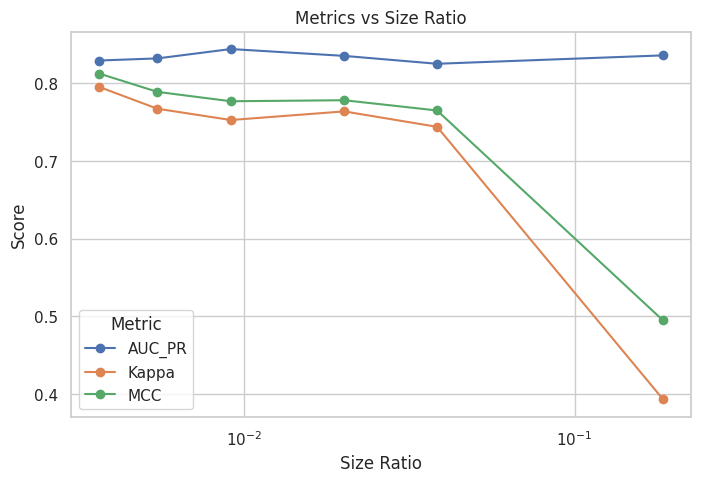

In [44]:
metrics = ['AUC_PR', 'Kappa', 'MCC']

res.plot(
    x='Size ratio',
    y=metrics,
    kind='line',
    marker='o',
    figsize=(8, 5),
    logx=True,
    title='Metrics vs Size Ratio'
)

plt.xlabel('Size Ratio')
plt.ylabel('Score')
plt.grid(True)
plt.legend(title='Metric')
plt.show()

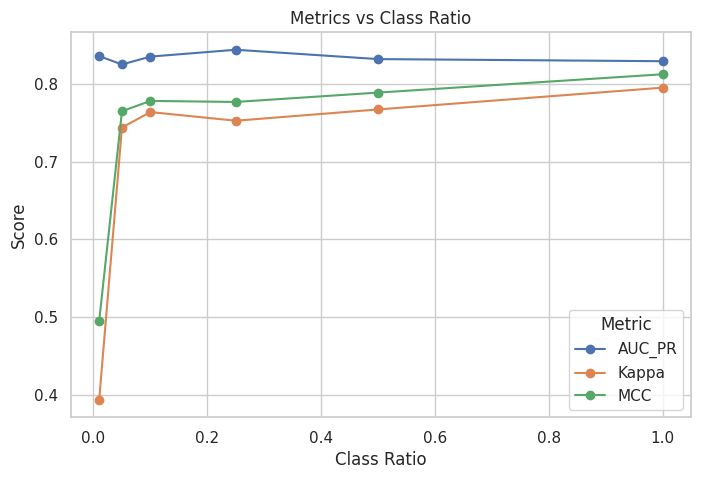

In [45]:
res.plot(
    x='Class ratio',
    y=metrics,
    kind='line',
    marker='o',
    figsize=(8, 5),
    title='Metrics vs Class Ratio'
)

plt.xlabel('Class Ratio')
plt.ylabel('Score')
plt.grid(True)
plt.legend(title='Metric')
plt.show()

Даже такой наивный подход может дать относительно неплохие результаты и улучшить наши метрики. Тем не менее, сейчас мы никак не используем информацию о распределении объектов в выборке. Оказывается, что даже относительно простые эвристические правила могут заметно поднять нам качество - например, мы можем при отбрасывании использовать близость отдельных объектов мажорного класса к минорному и отбрасывать самые близкие. Протестируйте алгоритм [Near-Miss](https://www.site.uottawa.ca/~nat/Workshop2003/jzhang.pdf) на наших данных и постройте графики, аналогичные предыдущему пункту (также добавьте график с зависимостью качества от числа соседей).

In [46]:
from imblearn.under_sampling import NearMiss

ns = [1, 5, 10, 25]

res = pd.DataFrame(columns=['Class ratio', 'Neighbours', 'Size ratio', 'AUC_PR', 'Kappa', 'MCC'])


i = 0
for n in ns:
    for ratio in ratios:
        miss = NearMiss(sampling_strategy=ratio, n_neighbors=n)
        X_resampled, y_resampled = miss.fit_resample(X_train, y_train)
        
        model = CatBoostClassifier(
            iterations=1000,
            depth=3,
            loss_function='Logloss',
            eval_metric='AUC',
            random_seed=12,
            verbose=0
        )

        model.fit(X_resampled, y_resampled, eval_set=(X_val, y_val), early_stopping_rounds=50)

        y_probs = model.predict_proba(X_test)[:, 1]
        y_pred = (y_probs >= best_threshold).astype(int)
        
        print(f'{"Class ratio:":<12} {ratio:<8.4f}')
        print(f'{"Neighbours:":<12} {n:<8}')
        # print(f'{"Size ratio:":<12} {X_resampled.shape[0] / X_train.shape[0]:<8.4f}')
        print(f'{"AUC-PR:":<12} {auc_pr(y_test, y_probs):<8.4f}')
        # print(f'{"Kappa:":<12} {kappa(y_test, y_pred):<8.4f}')
        # print(f'{"MCC:":<12} {MCC(y_test, y_pred):<8.4f}')
        print()
        res.loc[i] = [ratio, 
                      n,
                      X_resampled.shape[0] / X_train.shape[0], 
                      auc_pr(y_test, y_probs),
                      kappa(y_test, y_pred),
                      MCC(y_test, y_pred)
                    ]
        i += 1
    # print(res)

Class ratio: 0.0100  
Neighbours:  1       
AUC-PR:      0.7503  

Class ratio: 0.0500  
Neighbours:  1       
AUC-PR:      0.7204  

Class ratio: 0.1000  
Neighbours:  1       
AUC-PR:      0.7477  

Class ratio: 0.2500  
Neighbours:  1       
AUC-PR:      0.8043  

Class ratio: 0.5000  
Neighbours:  1       
AUC-PR:      0.7808  

Class ratio: 1.0000  
Neighbours:  1       
AUC-PR:      0.8002  

Class ratio: 0.0100  
Neighbours:  5       
AUC-PR:      0.5798  

Class ratio: 0.0500  
Neighbours:  5       
AUC-PR:      0.8080  

Class ratio: 0.1000  
Neighbours:  5       
AUC-PR:      0.7630  

Class ratio: 0.2500  
Neighbours:  5       
AUC-PR:      0.7554  

Class ratio: 0.5000  
Neighbours:  5       
AUC-PR:      0.7052  

Class ratio: 1.0000  
Neighbours:  5       
AUC-PR:      0.7934  

Class ratio: 0.0100  
Neighbours:  10      
AUC-PR:      0.8141  

Class ratio: 0.0500  
Neighbours:  10      
AUC-PR:      0.7759  

Class ratio: 0.1000  
Neighbours:  10      
AUC-PR:      0.816

In [47]:
res.sort_values('AUC_PR', ascending=False).head(3)

,Class ratio,Neighbours,Size ratio,AUC_PR,Kappa,MCC
14,0.10,10.0,0.020132,0.816157,0.00000,0.000000
12,0.01,10.0,0.184849,0.814130,0.34333,0.455237
17,1.00,10.0,0.003660,0.814001,0.00000,0.000000


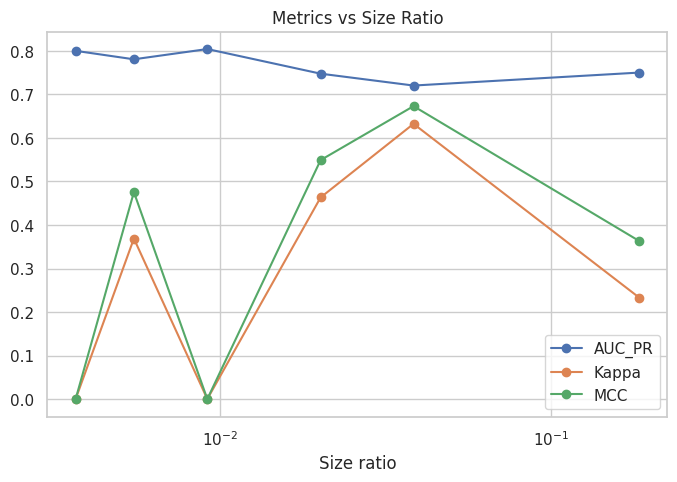

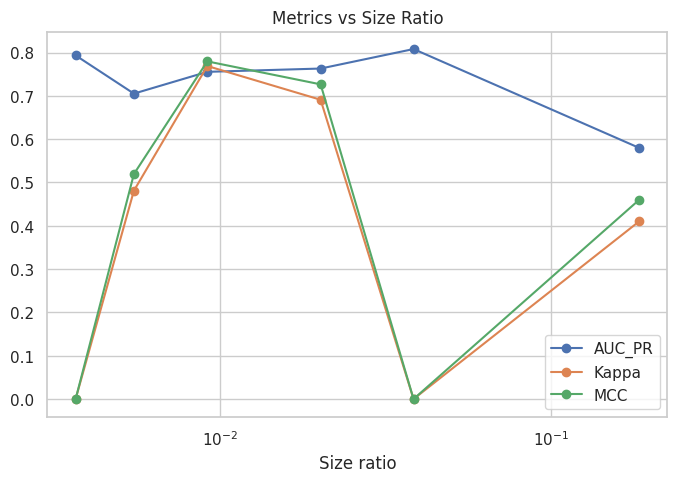

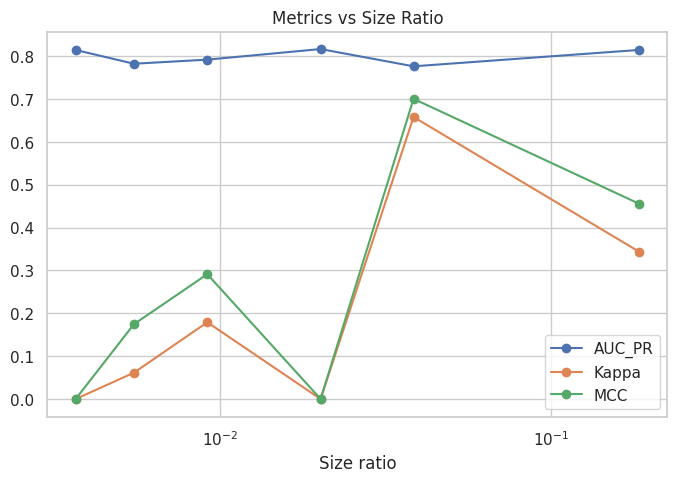

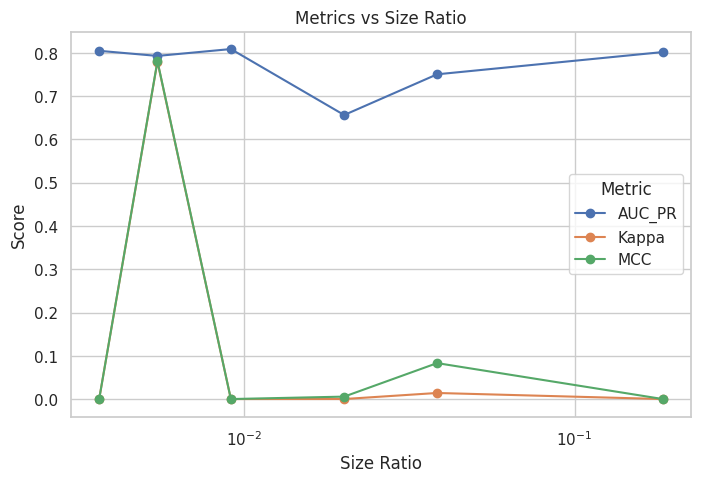

In [48]:
metrics = ['AUC_PR', 'Kappa', 'MCC']

res.groupby('Neighbours').plot(
    x='Size ratio',
    y=metrics,
    kind='line',
    marker='o',
    figsize=(8, 5),
    logx=True,
    title='Metrics vs Size Ratio'
)

plt.xlabel('Size Ratio')
plt.ylabel('Score')
plt.grid(True)
plt.legend(title='Metric')
plt.show()

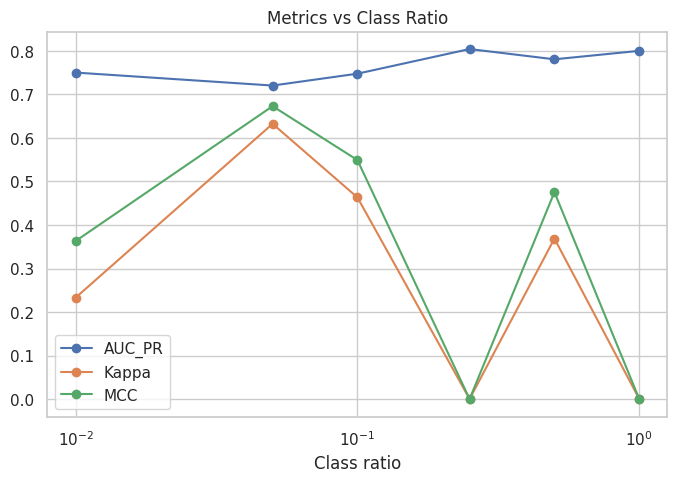

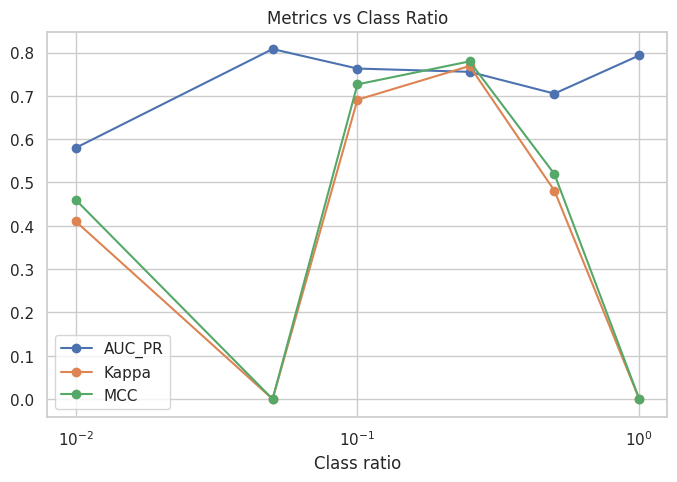

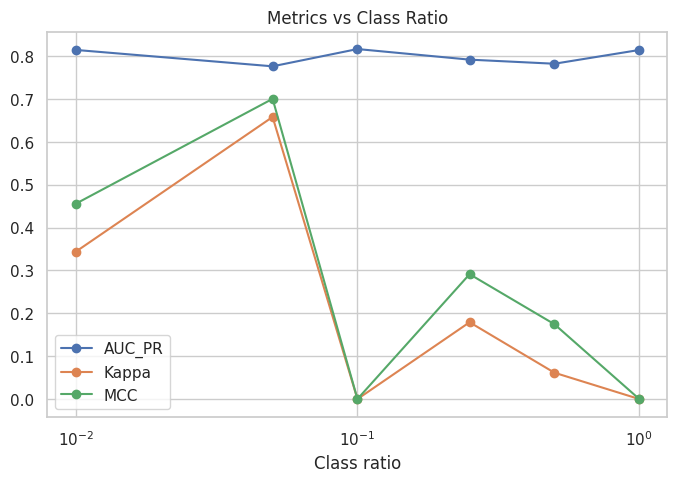

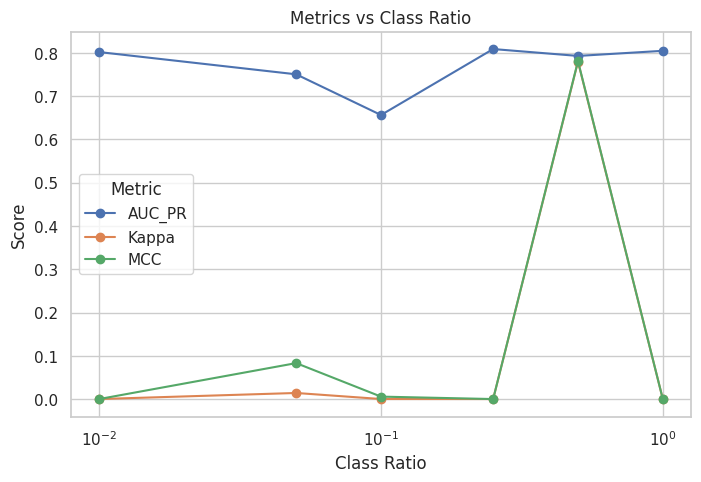

In [49]:
metrics = ['AUC_PR', 'Kappa', 'MCC']

res.groupby('Neighbours').plot(
    x='Class ratio',
    y=metrics,
    kind='line',
    marker='o',
    figsize=(8, 5),
    logx=True,
    title='Metrics vs Class Ratio'
)

plt.xlabel('Class Ratio')
plt.ylabel('Score')
plt.grid(True)
plt.legend(title='Metric')
plt.show()

# Часть 2. Поиск аномалий. 

Как вы могли заметить, методы балансировки выборок очень часто могут привести к не самым лучшим результатам из-за того, что они по сути искажают информацию о реальном распределении данных - в реальности обычно требуется долгий подбор в принципе работоспособных для задачи методов и их аккуратная настройка. 

Теперь давайте попробуем слегка сменить постановку задачи и переключиться на задачу "одноклассовой" классификации, то есть - поиска *аномалий* в выборке. В общем-то, это вполне согласуется с нашей областью работы - мы действительно можем назвать мошеннические транзакции аномальньми (как интуитивно, так и на основании наблюдаемой балансировки данных). 

Стоит отметить, что методы обнаружения аномалий чаще всего относятся к классу методов обучения без учителя. Это дает некоторый положительный эффект - нам не обязательно нужно тратить время на разметку данных (тем не менее, для контроля качества какую-то часть разметить все-таки придется). Впрочем, чаще всего перфоманс таких методов оказывается заметно хуже, чем у честного обучения с учителем (если мы можем себе его позволить).



**Задание 4. (3 балла).** На занятиях вы разбирали схожий с Random Forest подход для детекции аномалий без известной разметки данных, называемый Isolation Forest. Напомним суть: на этапе обучения мы создаем ансамбль из решающих деревьев, в котором признак и порог на каждую вершину подбираются случайно. Затем мы считаем для объектов оценку аномальности через длину пути до соответствующего листа в каждом дереве.

В данном задании вам предлагается реализовать модификацию данного алгоритма, известную как Extended Isolation Forest. В ней мы на каждом шаге будем определять не порог для признака, а полноценную случайную гиперплоскость, разбивающую выборку на 2 части. С детальным описанием вы можете ознакомиться [здесь](https://arxiv.org/pdf/1811.02141.pdf).

Ниже приведен шаблон кода. Постарайтесь работать в его рамках (минорные изменения вполне допустимы, главное не переворачивайте всю структуру с ног на голову). 

**NB**: будем считать, что в нашем датасете нет категориальных признаков - можете не заморачиваться с их обработкой (но в общем случае, это будет важно).

**Советы**:
 - Численные признаки лучше предобработать надлежащим образом.
 - Возможно, вам поможет выбрасывание некоторых признаков.
 - Внимательно следите за знаками.
 - Не игнорируйте документирующие строки.
 - Вероятнее всего, вы не сможете приблизиться по качеству к supervised-решениям. Если у вас не получается это сделать (но вы уверены в своей правоте), не стоит тратить слишком много времени на поиск ошибок.
- При желании, можете вынести этот код в отдельный файл и приложить его к ноутбуку. Он довольно громоздкий и в ноутбуке такое плохо читается.


**Бонусы (каждый по 0.5)**:
- Сделайте ваш EIF параллельным (`multiprocessing`, `joblib`).
- Добавьте возможность откатиться к дефолтному варианту Isolation Forest. (порассуждайте, как можно реализовать это в данной модели?):


In [21]:
%load_ext autoreload
%autoreload 2

In [52]:
from isoforest import * # Я вынес это для удобства в отдельный файл

**Задание 5. (1 балл).** Протестируйте вашу реализацию EIF и подберите оптимальные гиперпараметры (наш метод не использует разметку, поэтому можете попробовать делать это на обучающей выборке). Сравните ее с обычным IF из `sklearn` (желательно делать это на одних и тех же параметрах). Удалось ли сделать лучше?

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
from sklearn.metrics import roc_auc_score

n_trees_list = [30, 50, 100]
subsample_rates = [0.1, 0.2, 0.5]
thresholds = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7]
contamination = 0.01 

res = pd.DataFrame(columns=['Trees', 'Subsample', 'Threshold', 'AUC_PR', 'AUC-ROC', 'Kappa', 'MCC'])
i = 0

for n_trees in n_trees_list:
    for subsample in subsample_rates:
        print(f'{"N Trees:":<12} {n_trees:<12}')
        print(f'{"Subsample:":<12} {subsample:<12.4f}')

        model = ExtendedIsolationForest(
            n_trees=n_trees,
            subsample_rate=subsample,
            contamination=contamination
        )

        model.fit(X_train_scaled)
        scores = model.score_samples(X_test_scaled)
        
        best_threshold = 0
        best_mcc = -1

        for threshold in thresholds:
            y_pred = (scores >= threshold).astype(int)
            mcc = MCC(y_test, y_pred)
            if mcc > best_mcc:
                best_mcc = mcc
                best_threshold = threshold
        
        y_pred = (scores >= best_threshold).astype(int)

        print(f'{"Threshold:":<12} {best_threshold:<12.4f}')
        print(f'{"AUC-PR:":<12} {auc_pr(y_test, y_pred):<12.4f}')
        print(f'{"AUC-ROC:":<12} {roc_auc_score(y_test, y_pred):<12.4f}')
        print(f'{"Kappa:":<12} {kappa(y_test, y_pred):<12.4f}')
        print(f'{"MCC:":<12} {MCC(y_test, y_pred):<12.4f}')
        print()

        res.loc[i] = [n_trees,
                      subsample,
                      best_threshold, 
                      auc_pr(y_test, y_pred),
                      roc_auc_score(y_test, y_pred), 
                      kappa(y_test, y_pred),
                      MCC(y_test, y_pred)
                    ]
        i += 1


N Trees:     30          
Subsample:   0.1000      
Threshold:   0.0500      
AUC-PR:      0.4203      
AUC-ROC:     0.8815      
Kappa:       0.0867      
MCC:         0.1899      

N Trees:     30          
Subsample:   0.2000      
Threshold:   0.0500      
AUC-PR:      0.3929      
AUC-ROC:     0.8494      
Kappa:       0.1218      
MCC:         0.2177      

N Trees:     30          
Subsample:   0.5000      
Threshold:   0.0300      
AUC-PR:      0.3846      
AUC-ROC:     0.8332      
Kappa:       0.1551      
MCC:         0.2431      

N Trees:     50          
Subsample:   0.1000      
Threshold:   0.1000      
AUC-PR:      0.2768      
AUC-ROC:     0.7140      
Kappa:       0.1838      
MCC:         0.2242      

N Trees:     50          
Subsample:   0.2000      
Threshold:   0.0500      
AUC-PR:      0.3872      
AUC-ROC:     0.8411      
Kappa:       0.1336      
MCC:         0.2263      

N Trees:     50          
Subsample:   0.5000      
Threshold:   0.0300      
AUC-PR:

In [65]:
res

,Trees,Subsample,Threshold,AUC_PR,AUC-ROC,Kappa,MCC
0,30.0,0.1,0.05,0.420256,0.881469,0.086730,0.189915
1,30.0,0.2,0.05,0.392927,0.849380,0.121811,0.217673
2,30.0,0.5,0.03,0.384586,0.833168,0.155116,0.243147
3,50.0,0.1,0.10,0.276786,0.713973,0.183849,0.224237
4,50.0,0.2,0.05,0.387170,0.841106,0.133622,0.226339
5,50.0,0.5,0.03,0.398279,0.843059,0.168981,0.258397
6,100.0,0.1,0.10,0.262818,0.704399,0.170786,0.210466
7,100.0,0.2,0.05,0.395703,0.842689,0.160960,0.251328
8,100.0,0.5,0.03,0.387170,0.841106,0.133622,0.226339


In [66]:
res.sort_values('AUC_PR', ascending=False)

,Trees,Subsample,Threshold,AUC_PR,AUC-ROC,Kappa,MCC
0,30.0,0.1,0.05,0.420256,0.881469,0.086730,0.189915
5,50.0,0.5,0.03,0.398279,0.843059,0.168981,0.258397
7,100.0,0.2,0.05,0.395703,0.842689,0.160960,0.251328
1,30.0,0.2,0.05,0.392927,0.849380,0.121811,0.217673
4,50.0,0.2,0.05,0.387170,0.841106,0.133622,0.226339
8,100.0,0.5,0.03,0.387170,0.841106,0.133622,0.226339
2,30.0,0.5,0.03,0.384586,0.833168,0.155116,0.243147
3,50.0,0.1,0.10,0.276786,0.713973,0.183849,0.224237
6,100.0,0.1,0.10,0.262818,0.704399,0.170786,0.210466


Возможно, ваш алгоритм выдал большие оценки объектам с негативной разметкой. Постарайтесь выбрать несколько таких объектов и доступно объяснить (= с кодом и графиками), почему так вышло:

**Задание 6. (1 балл).** `sklearn` также предлагает нам и другие методы для поиска аномалий. В этом задании мы предлагаем вам сделать следующее:

Для начала попробуйте использовать методы Local Outlier Factor и One-Class SVM. Сравните результаты с IF и EIF.  

In [68]:
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import LocalOutlierFactor


n_neighbors = [10, 30, 50]
leaf_sizes = [20, 50, 100]
thresholds = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7]
contamination = 0.01 

res = pd.DataFrame(columns=['N Neighbours', 'Leaf size', 'Threshold', 'AUC_PR', 'AUC-ROC', 'Kappa', 'MCC'])
i = 0

for n_neigh in n_trees_list:
    for leaf_size in leaf_sizes:
        print(f'{"Neighbours:":<12} {n_neigh:<12}')
        print(f'{"Leaf size:":<12} {leaf_size:<12}')

        model = LocalOutlierFactor(
            n_neighbors=n_neigh, 
            contamination=contamination,
            metric='euclidean', 
            p=2,
            leaf_size=leaf_size,       
            novelty=True          
        )

        model.fit(X_train_scaled)
        scores = model.score_samples(X_test_scaled)
        
        best_threshold = 0
        best_mcc = -1

        for threshold in thresholds:
            y_pred = (scores >= threshold).astype(int)
            mcc = MCC(y_test, y_pred)
            if mcc > best_mcc:
                best_mcc = mcc
                best_threshold = threshold
        
        y_pred = (scores >= best_threshold).astype(int)

        print(f'{"Threshold:":<12} {best_threshold:<12.4f}')
        print(f'{"AUC-PR:":<12} {auc_pr(y_test, y_pred):<12.4f}')
        print(f'{"AUC-ROC:":<12} {roc_auc_score(y_test, y_pred):<12.4f}')
        print(f'{"Kappa:":<12} {kappa(y_test, y_pred):<12.4f}')
        print(f'{"MCC:":<12} {MCC(y_test, y_pred):<12.4f}')
        print()

        res.loc[i] = [n_trees,
                      subsample,
                      best_threshold, 
                      auc_pr(y_test, y_pred),
                      roc_auc_score(y_test, y_pred), 
                      kappa(y_test, y_pred),
                      MCC(y_test, y_pred)
                    ]
        i += 1


N Neighbours: 30          
Leaf size:   20          
Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5000      
Kappa:       0.0000      
MCC:         0.0000      

N Neighbours: 30          
Leaf size:   50          
Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5000      
Kappa:       0.0000      
MCC:         0.0000      

N Neighbours: 30          
Leaf size:   100         
Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5000      
Kappa:       0.0000      
MCC:         0.0000      

N Neighbours: 50          
Leaf size:   20          
Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5000      
Kappa:       0.0000      
MCC:         0.0000      

N Neighbours: 50          
Leaf size:   50          
Threshold:   0.0100      
AUC-PR:      0.5009      
AUC-ROC:     0.5000      
Kappa:       0.0000      
MCC:         0.0000      

N Neighbours: 50          
Leaf size:   100         
Threshold:   0.0100      
A

что-то с этим методом я сделал не так... еще и обучается он по пол часа

In [ ]:
# у меня все время крашилось ядро, поэтому я решил собрать все нужные штуки тут, чтобы не ходить далеко за ячейками
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score as precision, recall_score as recall, auc, precision_recall_curve
from sklearn.metrics import accuracy_score as accuracy, roc_auc_score
import pandas as pd

from isoforest import *

train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
test = pd.read_csv('test.csv')

def auc_pr(y_true, y_pred):
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    return auc(recall, precision)

def kappa(y_true, y_pred):
    p_o = accuracy(y_true, y_pred)
    a = y_true.mean() * y_pred.mean()
    b = (1 - y_true.mean()) * (1 - y_pred.mean())
    p_e = a + b
    return (p_o - p_e) / (1 - p_e)

def MCC(y_true, y_pred) -> float:
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))

    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    d = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    if d == 0.0:
        return 0.0
    
    return float(tp * tn - fp * fn) / np.sqrt(d)

X_train, y_train = train.drop(columns='Class'), train['Class']
X_test, y_test = test.drop(columns='Class'), test['Class']
X_val, y_val = val.drop(columns='Class'), val['Class']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score

kernels = ['linear', 'rbf', 'poly']
nu = 0.01
gammas = ['scale', 'auto']
thresholds = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7]

res = pd.DataFrame(columns=['Kernel','Gamma', 'Threshold', 'AUC_PR', 'AUC-ROC', 'Kappa', 'MCC'])
i = 0

for kernel in kernels:
    for gamma in gammas:
        print(f'{"Kernel:":<12} {kernel:<12}')
        print(f'{"Gamma:":<12} {gamma:<12}')

        model = OneClassSVM(
            kernel=kernel,
            nu=nu,
            gamma=gamma,
            shrinking=True, # for speed
            max_iter=1000,
            tol=1e-4
        )
        model.fit(X_train_scaled)
        scores = model.decision_function(X_test_scaled)
        
        scores = (scores - scores.min()) / (scores.max() - scores.min())
        
        best_threshold = 0
        best_mcc = -1

        for threshold in thresholds:
            y_pred = (scores >= threshold).astype(int)
            mcc = MCC(y_test, y_pred)
            if mcc > best_mcc:
                best_mcc = mcc
                best_threshold = threshold
        
        y_pred = (scores >= best_threshold).astype(int)

        print(f'{"Threshold:":<12} {best_threshold:<12.4f}')
        print(f'{"AUC-PR:":<12} {auc_pr(y_test, y_pred):<12.4f}') 
        print(f'{"AUC-ROC:":<12} {roc_auc_score(y_test, y_pred):<12.4f}')
        print(f'{"Kappa:":<12} {kappa(y_test, y_pred):<12.4f}')
        print(f'{"MCC:":<12} {MCC(y_test, y_pred):<12.4f}')
        print()

        res.loc[i] = [kernel,
                        gamma,
                        best_threshold, 
                        auc_pr(y_test, y_pred),
                        roc_auc_score(y_test, y_pred), 
                        kappa(y_test, y_pred),
                        MCC(y_test, y_pred)]
        i += 1

Kernel:      linear      
Gamma:       scale       


/home/sacr1ficerq/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Threshold:   0.3000      
AUC-PR:      0.0919      
AUC-ROC:     0.5723      
Kappa:       0.0198      
MCC:         0.0396      

Kernel:      linear      
Gamma:       auto        


/home/sacr1ficerq/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Threshold:   0.3000      
AUC-PR:      0.0919      
AUC-ROC:     0.5723      
Kappa:       0.0198      
MCC:         0.0396      

Kernel:      rbf         
Gamma:       scale       


...

Threshold:   0.7000      
AUC-PR:      0.0009      
AUC-ROC:     0.3784      
Kappa:       -0.0037     
MCC:         -0.0245     

Kernel:      poly        
Gamma:       scale       


/home/sacr1ficerq/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Threshold:   0.7000      
AUC-PR:      0.0009      
AUC-ROC:     0.5000      
Kappa:       -0.0001     
MCC:         -0.0003     

Kernel:      poly        
Gamma:       auto        


/home/sacr1ficerq/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Threshold:   0.7000      
AUC-PR:      0.0009      
AUC-ROC:     0.5000      
Kappa:       -0.0001     
MCC:         -0.0003     



In [5]:
res

,Kernel,Gamma,Threshold,AUC_PR,AUC-ROC,Kappa,MCC
0,linear,scale,0.3,0.091894,0.572330,0.019767,0.039610
1,linear,auto,0.3,0.091894,0.572330,0.019767,0.039610
2,rbf,scale,0.7,0.000930,0.378373,-0.003707,-0.024451
3,rbf,auto,0.7,0.000930,0.378373,-0.003707,-0.024451
4,poly,scale,0.7,0.000930,0.499982,-0.000069,-0.000256
5,poly,auto,0.7,0.000930,0.499982,-0.000069,-0.000256


Тоже обучается сто лет, если без лайфхаков. Качества нормального я тоже не смог добиться. MCC вообще не получается поднять никак, хотя в интернетах пишут, что это state of the art метод.

Поэтому будем использовать только самодельный eiForest.

У вас началась депрессия из-за плохих метрик? Не беда! Сейчас давайте сделаем так: все методы, опробованные в этой части, попробуем задействовать для создания дополнительных признаков в данных. Проделайте это (не забудьте, что обучаться здесь нужно на трейне). Теперь возьмите лучшую модель из предыдущей части и обучите на новых данных. Смогли ли unsupervised-методы повысить вам качество?

Так как признак аномалия объект или нет определяется по скору, добавим только скор.

In [ ]:
model = ExtendedIsolationForest(
    n_trees=30,
    subsample_rate=0.1,
    contamination=0.01
)
model.fit(X_train_scaled)
scores = model.score_samples(X_train_scaled)


In [18]:
X_train['Isolation Score'] = scores

In [21]:
X_train

,Unnamed: 0,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V23,V24,V25,V26,V27,V28,Amount,hour,day,Isolation Score
0,0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0,0.0,0.030371
1,1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0,0.0,0.028061
2,2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0,0.0,0.043743
3,3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0,0.0,0.036498
4,4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0,0.0,0.031388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227841,227841,145245.0,0.306600,1.116021,-0.047348,3.593785,2.079047,5.748707,-2.059246,-1.352120,...,0.258831,0.639005,-0.048250,0.144586,0.216385,0.304545,0.76,16.0,1.0,0.040431
227842,227842,145245.0,-1.781954,2.062680,-3.758871,-1.801001,-0.084365,1.919610,-1.454364,-9.825473,...,-0.339706,-0.216688,-1.555393,0.655873,0.777662,0.272753,359.28,16.0,1.0,0.062909
227843,227843,145245.0,-0.061507,1.024900,-0.170060,-0.263220,0.982164,-1.162749,1.468942,-0.648407,...,-0.296209,-0.140335,-0.465171,-0.197933,-0.048916,0.023871,39.40,16.0,1.0,0.029050
227844,227844,145247.0,2.050034,-0.103557,-1.204713,0.207198,0.108850,-0.665621,0.073598,-0.164464,...,0.280573,-0.405691,-0.274672,0.202719,-0.074529,-0.074279,0.17,16.0,1.0,0.027008


In [9]:
scores_test = model.score_samples(X_test_scaled)
X_test['Isolation Score'] = scores_test

In [25]:
from imblearn.under_sampling import RandomUnderSampler
from catboost import CatBoostClassifier
undersampler = RandomUnderSampler(sampling_strategy=0.01, random_state=12)
X_resampled, y_resampled = undersampler.fit_resample(X_train.drop(columns='Isolation Score'), y_train)

model = CatBoostClassifier(
    iterations=1000,
    depth=3,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=12,
    verbose=0
)
model.fit(X_resampled, y_resampled)
y_probs = model.predict_proba(X_test)[:, 1]

y_pred = (y_probs > 0.5).astype(int)

print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_pred):<8.4f}')
print(f'{"Kappa:":<8} {kappa(y_test, y_pred):<8.4f}')
print(f'{"MCC:":<8} {MCC(y_test, y_pred):<8.4f}')

AUC-PR:  0.8426  
Kappa:   0.8365  
MCC:     0.8393  


In [26]:
undersampler = RandomUnderSampler(sampling_strategy=0.01, random_state=12)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

model = CatBoostClassifier(
    iterations=1000,
    depth=3,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=12,
    verbose=0
)
model.fit(X_resampled, y_resampled)
y_probs = model.predict_proba(X_test)[:, 1]

y_pred = (y_probs > 0.5).astype(int)

print(f'{"AUC-PR:":<8} {auc_pr(y_test, y_pred):<8.4f}')
print(f'{"Kappa:":<8} {kappa(y_test, y_pred):<8.4f}')
print(f'{"MCC:":<8} {MCC(y_test, y_pred):<8.4f}')

AUC-PR:  0.8327  
Kappa:   0.8280  
MCC:     0.8301  


Катарсиса у меня не получилось. Факир был пьян и фокус не удался.

**Бонус. (0.1 балла).**

При сдаче проверяющий запустит следующую клетку один раз. Если она даст положительный результат, вы получите 0.1 бонусных балла. Если она даст отрицательный результат, вы получите -0.1 бонусных балла. 

Если вы хотите отказаться от сдачи данного задания, допишите "хочу" после двоеточия: **`обожаю гамблинг`**

Ниже вы можете попрактиковаться и оценить ваши силы (изменять код ячейки запрещается!)

In [ ]:
import random

rng = random.SystemRandom(0)
rng.uniform(-1.0, 1.0)

-0.17215727613067022